# Analiza cen wynajmu mieszkań w Szczecinie

## Celem projektu jest prosta analiza ofert wynajmu mieszkań w Szczecinie na podstawie danych z okresu listopad 2023 - czerwiec 2024.

## Import wymaganych bibliotek

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Przygotowanie listy plików z danymi

In [2]:
dane = [
    ("Dane/apartments_rent_pl_2023_11.csv", "2023-11"),
    ("Dane/apartments_rent_pl_2023_12.csv", "2023-12"),
    ("Dane/apartments_rent_pl_2024_01.csv", "2024-01"),
    ("Dane/apartments_rent_pl_2024_02.csv", "2024-02"),
    ("Dane/apartments_rent_pl_2024_03.csv", "2024-03"),
    ("Dane/apartments_rent_pl_2024_04.csv", "2024-04"),
    ("Dane/apartments_rent_pl_2024_05.csv", "2024-05"),
    ("Dane/apartments_rent_pl_2024_06.csv", "2024-06")
]

## Wczytanie i połączenie danych

In [5]:
lista_danych = []

for plik, miesiac in dane:
    dane_miesiac = pd.read_csv(plik)
    dane_miesiac["month"] = miesiac
    lista_danych.append(dane_miesiac)

df = pd.concat(lista_danych, ignore_index=True)

df.head(10)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,month
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.00,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,condominium,brick,NaN,yes,yes,no,no,no,3500,2023-11
1,5a0cb42c088eadf75aa98a4118640048,szczecin,blockOfFlats,57.00,3.0,NaN,10.0,1976.0,53.440955,14.566024,...,condominium,NaN,premium,no,yes,yes,no,no,3000,2023-11
2,996722490efcb4b34d48bb84a9a72838,szczecin,NaN,43.40,2.0,3.0,4.0,NaN,53.435746,14.560764,...,condominium,NaN,NaN,no,yes,no,no,no,1900,2023-11
3,50d75c688530b9a61ba505301e0b94a9,szczecin,apartmentBuilding,32.60,2.0,5.0,6.0,2021.0,53.421582,14.541572,...,condominium,brick,premium,no,yes,yes,no,no,2500,2023-11
4,9b187f4203adabf466fd08610d8f4e5e,szczecin,apartmentBuilding,72.00,3.0,6.0,6.0,2014.0,53.450010,14.547230,...,condominium,brick,premium,no,yes,yes,no,yes,2999,2023-11
5,ba4d70d65d1024ee13929ca82bfc92f6,szczecin,blockOfFlats,52.00,2.0,1.0,3.0,2006.0,53.427400,14.488100,...,condominium,concreteSlab,NaN,yes,no,no,no,no,2300,2023-11
6,195bf5124c9fd720ca3ff7aeff9ca83f,szczecin,blockOfFlats,45.94,2.0,4.0,10.0,1978.0,53.433567,14.539891,...,condominium,concreteSlab,NaN,no,yes,yes,no,no,2500,2023-11
7,03a41e8ec8ebdc1dd5a86d65ae3de54e,szczecin,blockOfFlats,54.00,2.0,NaN,3.0,2002.0,53.412600,14.541100,...,condominium,brick,premium,yes,yes,yes,no,yes,2600,2023-11
8,aae4994ab375e107dcc375f3360bd3d9,szczecin,tenement,32.00,1.0,2.0,4.0,1930.0,53.434836,14.548864,...,condominium,brick,premium,no,no,NaN,no,no,1500,2023-11
9,b83458393eb79b3ecdb13de56a6e2676,szczecin,blockOfFlats,76.38,3.0,1.0,1.0,1954.0,53.435478,14.512039,...,condominium,brick,premium,yes,no,no,no,no,3600,2023-11


## Sprawdzenie rozmiaru danych, liczby wierszy i kolumn

In [6]:
df.shape

(70847, 29)

# Podstawowe informacje o danych

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70847 entries, 0 to 70846
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    70847 non-null  object 
 1   city                  70847 non-null  object 
 2   type                  54085 non-null  object 
 3   squareMeters          70847 non-null  float64
 4   rooms                 70847 non-null  float64
 5   floor                 62234 non-null  float64
 6   floorCount            69468 non-null  float64
 7   buildYear             51165 non-null  float64
 8   latitude              70847 non-null  float64
 9   longitude             70847 non-null  float64
 10  centreDistance        70847 non-null  float64
 11  poiCount              70847 non-null  float64
 12  schoolDistance        70832 non-null  float64
 13  clinicDistance        70797 non-null  float64
 14  postOfficeDistance    70821 non-null  float64
 15  kindergartenDistanc

Dane mają 70847 wierszy i 29 kolumn. Na tym etapie widać, że część kolumn posiada braki danych, np. `type`, `floor` i inne. Braki zostaną dokładniej sprawdzone w dalszej części projektu.

## Sprawdzenie nazw kolumn

In [9]:
df.columns

Index(['id', 'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition',
       'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
       'hasStorageRoom', 'price', 'month'],
      dtype='object')

W danych znajdują się informacje między innymi o mieście, cenie, metrażu, liczbie pokoi, piętrze, roku budowy, odległościach od różnych punktów oraz dodatkowych cechach mieszkania.

## Sprawdzenie dostępnych miast

In [12]:
df["city"].value_counts()

city
warszawa       28414
krakow         12661
wroclaw         6676
lodz            5214
poznan          3890
gdansk          3595
katowice        2669
gdynia          1483
szczecin        1482
bydgoszcz       1478
lublin          1313
czestochowa      661
rzeszow          614
bialystok        440
radom            257
Name: count, dtype: int64

Najwięcej ofert znajduje się w Warszawie oraz Krakowie, najmniej w Częstochowie, Rzeszowie, Białymstoku i Radomiu.

W danych znajduje się wiele miast, do analizy wybrany został Szczecin. W danych znajduje się 1482 ofert z tego miasta.

In [34]:
szczecin = df[df["city"] == "szczecin"].copy()

szczecin.shape

(1482, 29)

## Podgląd danych dla Szczecina

In [14]:
szczecin.head()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,month
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,condominium,brick,NaN,yes,yes,no,no,no,3500,2023-11
1,5a0cb42c088eadf75aa98a4118640048,szczecin,blockOfFlats,57.0,3.0,NaN,10.0,1976.0,53.440955,14.566024,...,condominium,NaN,premium,no,yes,yes,no,no,3000,2023-11
2,996722490efcb4b34d48bb84a9a72838,szczecin,NaN,43.4,2.0,3.0,4.0,NaN,53.435746,14.560764,...,condominium,NaN,NaN,no,yes,no,no,no,1900,2023-11
3,50d75c688530b9a61ba505301e0b94a9,szczecin,apartmentBuilding,32.6,2.0,5.0,6.0,2021.0,53.421582,14.541572,...,condominium,brick,premium,no,yes,yes,no,no,2500,2023-11
4,9b187f4203adabf466fd08610d8f4e5e,szczecin,apartmentBuilding,72.0,3.0,6.0,6.0,2014.0,53.450010,14.547230,...,condominium,brick,premium,no,yes,yes,no,yes,2999,2023-11


## Sprawdzenie informacji o danych dla Szczecina

In [15]:
szczecin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1482 entries, 0 to 62168
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1482 non-null   object 
 1   city                  1482 non-null   object 
 2   type                  1174 non-null   object 
 3   squareMeters          1482 non-null   float64
 4   rooms                 1482 non-null   float64
 5   floor                 1287 non-null   float64
 6   floorCount            1460 non-null   float64
 7   buildYear             1246 non-null   float64
 8   latitude              1482 non-null   float64
 9   longitude             1482 non-null   float64
 10  centreDistance        1482 non-null   float64
 11  poiCount              1482 non-null   float64
 12  schoolDistance        1482 non-null   float64
 13  clinicDistance        1482 non-null   float64
 14  postOfficeDistance    1482 non-null   float64
 15  kindergartenDistance  148

## Poprawienie typów wybranych kolumn

In [ ]:
szczecin["rooms"] = szczecin["rooms"].astype(int)
szczecin["floor"] = szczecin["floor"].round().astype(int)
szczecin["floorCount"] = szczecin["floorCount"].round().astype(int)
szczecin["buildYear"] = szczecin["buildYear"].round().astype(int)

Dane dla Szczecina mają 1482 wiersze i 29 kolumn. Widać, że część kolumn ma braki danych.

## Sprawdzenie duplikatów

In [16]:
szczecin.duplicated().sum()

np.int64(0)

Zbiór nie zawiera duplikatów.

In [19]:
szczecin["id"].nunique()

719

W danych dla Szczecina znajduje się 1482 obserwacji, ale tylko 719 unikalnych identyfikatorów ofert. Oznacza to, że część ofert pojawiała się w więcej niż jednym miesiącu. Nie traktujemy tego jako błąd, ponieważ analizujemy dane z kilku miesięcy.

## Sprawdzenie braków danych

In [18]:
braki = pd.DataFrame({
    "liczba_brakow": szczecin.isna().sum(),
    "procent_brakow": round(szczecin.isna().mean() * 100, 2)
})

braki = braki[braki["liczba_brakow"] > 0]
braki = braki.sort_values("procent_brakow", ascending=False)

braki

,liczba_brakow,procent_brakow
condition,550,37.11
buildingMaterial,362,24.43
type,308,20.78
buildYear,236,15.92
floor,195,13.16
hasElevator,156,10.53
collegeDistance,52,3.51
floorCount,22,1.48


Najwięcej braków danych występuje w kolumnach `condition`, `buildingMaterial`, `type`, `buildYear`, `floor` oraz `hasElevator`. Braki dotyczą głównie cech opisowych mieszkania i budynku.

## Heatmapa braków danych

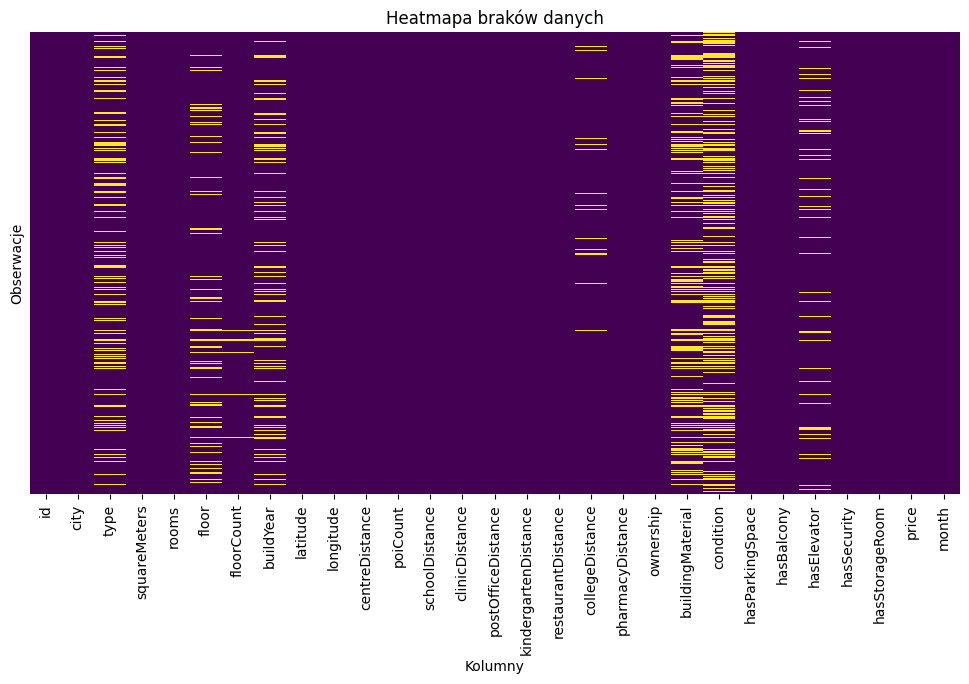

In [35]:
plt.figure(figsize=(12, 6))

sns.heatmap(szczecin.isna(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Heatmapa braków danych")
plt.xlabel("Kolumny")
plt.ylabel("Obserwacje")

plt.show()

Heatmapa pozwala nam zobrazować, jak rozkładają się braki danych dla całego zbioru.

In [25]:
szczecin[["price", "squareMeters", "rooms", "floor", "floorCount", "buildYear"]].describe()

,price,squareMeters,rooms,floor,floorCount,buildYear
count,1482.000000,1482.000000,1482.000000,1287.000000,1460.000000,1246.000000
mean,2632.659919,51.531242,2.246289,3.084693,4.976712,1990.968700
std,732.369461,19.567319,0.831968,1.970184,3.755481,32.142526
min,1300.000000,25.000000,1.000000,1.000000,1.000000,1897.000000
25%,2100.000000,37.000000,2.000000,2.000000,3.000000,1970.000000
50%,2500.000000,47.550000,2.000000,3.000000,4.000000,2004.000000
75%,2999.750000,61.000000,3.000000,4.000000,5.000000,2018.000000
max,5000.000000,140.000000,6.000000,13.000000,28.000000,2024.000000


## Usunięcie ujemnych wartości, jeśli występują

In [36]:
liczba_przed = len(szczecin)

szczecin = szczecin[szczecin["price"] > 0]
szczecin = szczecin[szczecin["squareMeters"] > 0]
szczecin = szczecin[szczecin["rooms"] > 0]

liczba_po = len(szczecin)
liczba_usunietych = liczba_przed - liczba_po

print("Liczba wierszy przed czyszczeniem:", liczba_przed)
print("Liczba wierszy po czyszczeniu:", liczba_po)
print("Liczba usuniętych wierszy:", liczba_usunietych)

Liczba wierszy przed czyszczeniem: 1482
Liczba wierszy po czyszczeniu: 1482
Liczba usuniętych wierszy: 0


## Uzupełnienie braków danych metodą hot-deck

In [37]:
def wypelnij_hotdeck(dane, kolumna):
    braki = dane[kolumna].isna()
    ile_brakow = braki.sum()
    
    if ile_brakow > 0:
        dostepne_wartosci = dane.loc[~braki, kolumna]
        wylosowane_wartosci = dostepne_wartosci.sample(
            n=ile_brakow,
            replace=True,
            random_state=42
        ).values
        
        dane.loc[braki, kolumna] = wylosowane_wartosci
    
    return dane

In [39]:
szczecin.isna().sum().sum()

np.int64(1881)

## Wybranie kolumn z brakami danych

In [40]:
kolumny_z_brakami = szczecin.columns[szczecin.isna().sum() > 0]

kolumny_z_brakami

Index(['type', 'floor', 'floorCount', 'buildYear', 'collegeDistance',
       'buildingMaterial', 'condition', 'hasElevator'],
      dtype='object')

## Uzupełnienie braków w wybranych kolumnach

In [41]:
for kolumna in kolumny_z_brakami:
    szczecin = wypelnij_hotdeck(szczecin, kolumna)

## Sprawdzenie braków po uzupełnieniu

In [42]:
szczecin.isna().sum().sum()

np.int64(0)

Po uzupełnieniu danych tabela braków jest pusta, co oznacza, że wszystkie brakujące wartości zostały uzupełnione.

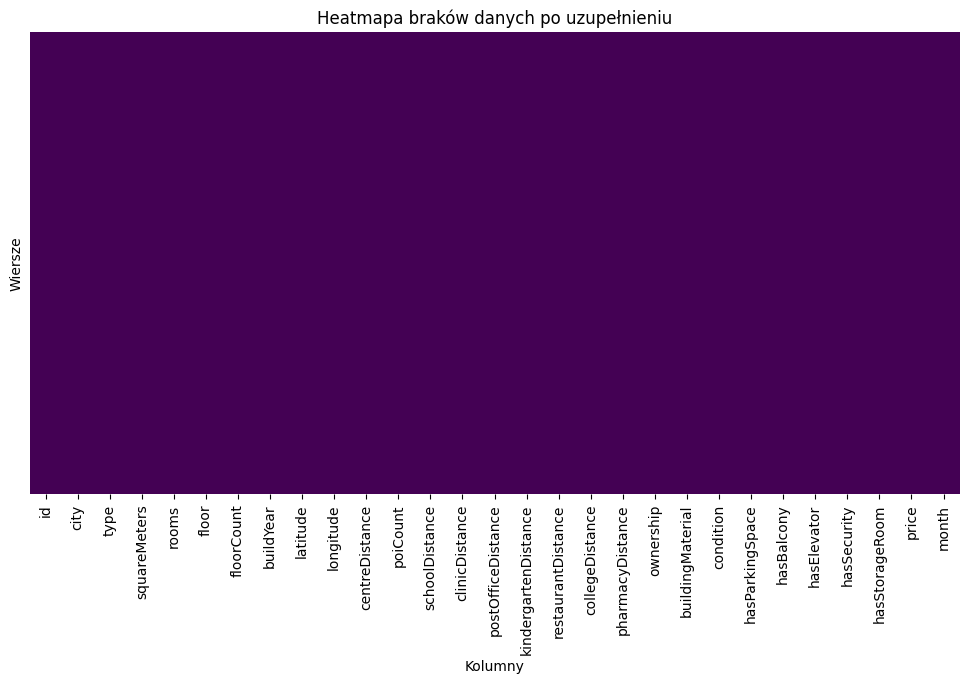

In [43]:
plt.figure(figsize=(12, 6))

sns.heatmap(szczecin.isna(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Heatmapa braków danych po uzupełnieniu")
plt.xlabel("Kolumny")
plt.ylabel("Wiersze")

plt.show()